<div align="center">

# Hierarchical Clustering on Movies Dataset

</div>


In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore')

____
### 🟣 Agglomerative Clustering (Hierarchical) – Setup

In [171]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import fcluster
from sklearn.decomposition import PCA


In [172]:
data = pd.read_csv('tmdb_movies_cleaned.csv')

In [173]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9953 entries, 0 to 9952
Data columns (total 46 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          9953 non-null   int64  
 1   title                       9953 non-null   object 
 2   runtime                     9953 non-null   int64  
 3   release_date                9953 non-null   object 
 4   budget                      9953 non-null   int64  
 5   revenue                     9953 non-null   int64  
 6   popularity                  9953 non-null   float64
 7   vote_average                9953 non-null   float64
 8   vote_count                  9953 non-null   int64  
 9   belongs_to_collection       9953 non-null   int64  
 10  has_tagline                 9953 non-null   int64  
 11  has_homepage                9953 non-null   int64  
 12  num_same_title              9953 non-null   int64  
 13  changed_title               9953 

In [174]:
data.columns

Index(['id', 'title', 'runtime', 'release_date', 'budget', 'revenue',
       'popularity', 'vote_average', 'vote_count', 'belongs_to_collection',
       'has_tagline', 'has_homepage', 'num_same_title', 'changed_title',
       'num_genres', 'Comedy', 'Action', 'Animation', 'Drama', 'History',
       'Family', 'War', 'Thriller', 'Crime', 'Adventure', 'Music', 'Fantasy',
       'Science Fiction', 'TV Movie', 'Western', 'Documentary', 'Romance',
       'Mystery', 'Horror', 'top10_prod_comps', 'num_production_companies',
       'main_production_country', 'num_production_countries',
       'num_spoken_languages', 'is_english_spoken', 'popularity_percentile',
       'weighted_rating', 'release_year', 'season',
       'return_on_investment_ratio', 'profit_or_loss'],
      dtype='object')

### 🔍 Focusing on Hierarchical Clustering: Why Data Adjustments Are Necessary

As we shift our focus to hierarchical clustering and research questions that align with its unique strengths, we are adapting our dataset accordingly.

Hierarchical algorithms are **especially sensitive to certain data issues**, which makes preprocessing critical:

- **High sensitivity to outliers** – A single extreme value can distort entire branches of the dendrogram, making it harder to interpret the true structure.
- **Low scalability** – The algorithm doesn't perform well when the dataset includes a lot of noise or irrelevant features.
- **Key advantage** – When the data is well-prepared, hierarchical clustering excels at uncovering complex nested structures that other methods might miss.

These characteristics justify applying specific filters, transformations, or feature selections tailored to improve hierarchical clustering results.
_____

In [175]:
from sklearn.preprocessing import StandardScaler

____
### 🔍 Outlier Inspection Strategy

Hierarchical clustering is highly sensitive to outliers, as they can significantly distort distance calculations and the resulting cluster structure.  
At first, we considered removing outliers once at the beginning of the project, but we noticed that this approach **removed too much valuable data**, even in cases where the outliers were not relevant to certain features.

#### ✅ Our Chosen Approach: Outlier Removal Per Question

To avoid unnecessary data loss, we decided to **inspect and remove outliers separately for each clustering question**, based only on the features used in that specific analysis.

This approach allows us to maintain a larger and more relevant dataset for each question, while still protecting the algorithm from distortion caused by extreme values.

- ✔️ **Preserves more data**: We avoid removing rows that might be useful in other questions.
- ✔️ **Improves clustering accuracy**: Each question works with a clean and focused subset of features.
- ✔️ **Ensures transparency**: We clearly state that outliers were removed only based on the features involved in each question.

This strategy balances data quality with completeness and supports more meaningful and robust hierarchical clustering results.


____
____

📝 Rationale for Choosing Questions and Features for Hierarchical Clustering
Given the complete set of available features, I selected specific analytical questions tailored to the hierarchical clustering algorithm. These questions were carefully chosen to highlight the algorithm's inherent strengths, particularly its ability to identify nested or hierarchical structures, and its effectiveness in handling various distance metrics. By formulating each question around specific combinations of features, I aimed to thoroughly evaluate the clustering performance and demonstrate clearly how hierarchical clustering provides valuable insights into the data structure.

____
## 📅 Can movies be grouped by their release year without explicitly using the year?

### 🔍 **What we check:**
- Use only features that we assume naturally change over time:
  - **Budget**
  - **Runtime**
  - **Revenue**
- Do **not** include the release year itself as a feature.
- Evaluate if the algorithm can implicitly identify natural groupings based on the period when the movies were released (e.g., movies released before 2000 versus newer movies).

### 🎯 **What we expect to see:**
- Clearly separated groups corresponding to different release periods, indicating that these features effectively reflect temporal trends.

### ✅ **Advantage:**
- Tests the algorithm's ability to uncover hidden temporal patterns without directly relying on the release year.


In [215]:
features = ['budget', 'runtime', 'revenue']
data_filtered = data.dropna(subset=features + ['release_year']) 

print(f"📋 Observations before outlier removal: {len(data_filtered)}")

# ---------- outlier removal IQR ----------
def remove_outliers_iqr(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df

data_filtered = remove_outliers_iqr(data_filtered, features)
print(f"✅ Observations after outlier removal: {len(data_filtered)}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_filtered[features])

📋 Observations before outlier removal: 9953
✅ Observations after outlier removal: 7677


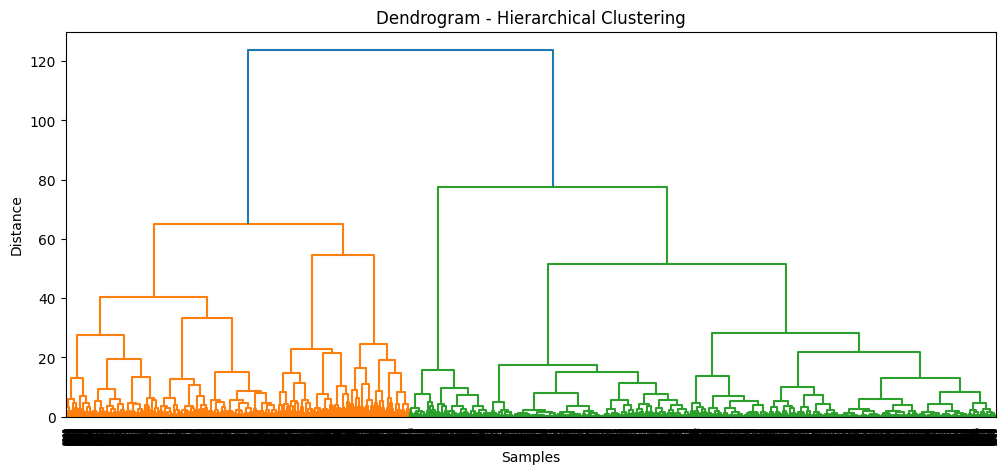

In [216]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(linked, truncate_mode='level', p=20)
plt.title('Dendrogram - Hierarchical Clustering')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

In [217]:
model = AgglomerativeClustering(n_clusters=3, linkage='ward')
clusters = model.fit_predict(X_scaled)

In [218]:
data_filtered['cluster'] = clusters

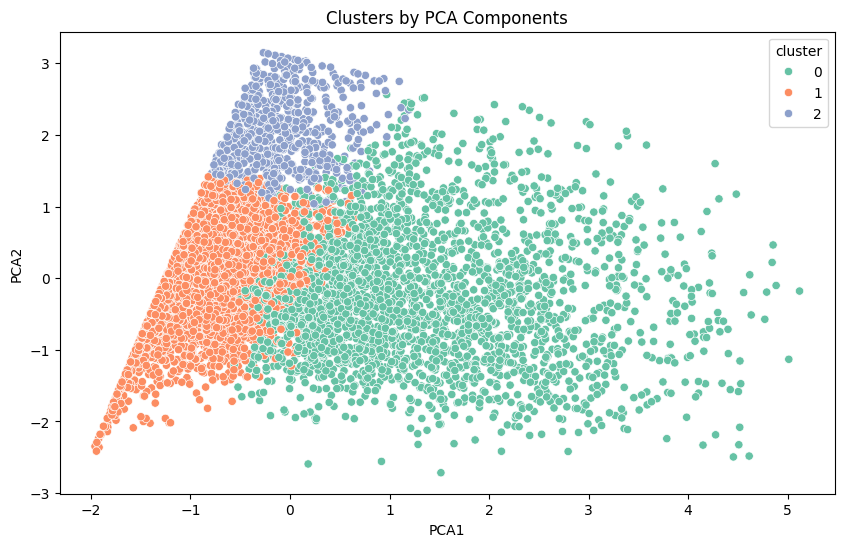

In [219]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
data_filtered['cluster'] = clusters
data_filtered['PCA1'] = X_pca[:, 0]
data_filtered['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=data_filtered, x='PCA1', y='PCA2', hue='cluster', palette='Set2')
plt.title('Clusters by PCA Components')
plt.show()


In [220]:
# 🔎 Explained variance
explained_var = pca.explained_variance_ratio_
total_var = explained_var.sum()
print(f"Total variance explained (3D): {total_var:.2%}")

Total variance explained (3D): 83.70%


In [221]:
from sklearn.decomposition import PCA
import plotly.express as px

# ביצוע PCA עם 3 רכיבים
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

# הוספת רכיבי PCA לדאטה
data_filtered['PCA1'] = X_pca_3d[:, 0]
data_filtered['PCA2'] = X_pca_3d[:, 1]
data_filtered['PCA3'] = X_pca_3d[:, 2]
data_filtered['cluster'] = clusters  # ודאי שהמשתנה clusters קיים

# תצוגת scatter תלת־ממדית
fig = px.scatter_3d(
    data_filtered, x='PCA1', y='PCA2', z='PCA3',
    color='cluster', opacity=0.6,
    title='3D Clustering Visualization with PCA'
)
fig.show()


In [222]:
# 🔎 Explained variance
explained_var = pca_3d.explained_variance_ratio_
total_var = explained_var.sum()
print(f"Total variance explained (3D): {total_var:.2%}")

Total variance explained (3D): 100.00%


In [193]:
stats = data_filtered.groupby('cluster')['release_year'].agg(
    mean_release_year='mean',
    median_release_year='median',
    min_release_year='min',
    max_release_year='max',
    count='count'
)

print("📊 Release year statistics per cluster:\n")
stats

📊 Release year statistics per cluster:



,mean_release_year,median_release_year,min_release_year,max_release_year,count
cluster,,,,,
0,"2,001","2,004",1939,2025,2841
1,"1,994","2,003",1913,2023,4161
2,"1,998","2,009",1922,2022,675


Although we assumed that financial features (such as budget and revenue) might indirectly reflect the release period of films, the clustering results suggest otherwise.

The clusters formed show high internal variance in release years and substantial overlap. Therefore, no clear segmentation by release period emerged, indicating that year-related patterns were not captured through the selected financial attributes.
אם מתקבל הבדל ברור בין ממוצעי השנים של הקלאסטרים — זה אומר שהפיצול כן הצליח "לזהות" קבוצות שונות גם בלי לראות את השנה בעצמה.

+להכניס הסבר על ניסיונות K שונים 
+ להנכיס הסבר על נסיות שיטות קישור שונות

____
____

## 🎯 Research Question:  
Can we identify groups of movies with different success levels — **based only on early features before release** — without using profit or popularity as input?

### 💡 Why Hierarchical Clustering?  
Hierarchical clustering allows us to explore whether **natural groups** exist based on early features such as `budget`, `runtime`, `release_year`, and `num_genres`.  
Since we don't know how many types of "potential success" exist, hierarchical clustering is ideal — we can observe the full structure and explore meaningful splits.

After clustering, we evaluated whether the groups differed in actual success:  
- ✅ When using **`profit_or_loss`** as a post-clustering label, the clusters showed clear separation.  
- ❌ When using **`popularity`**, the distinction between clusters was weaker.

### 📌 Conclusion:  
This question is well-suited for hierarchical clustering because it uncovers structure **without assuming labels**, and allows for **retrospective evaluation** of real-world outcomes.


In [223]:
features = ['budget', 'num_genres', 'num_production_companies', 'release_year']
data_filtered = data.dropna(subset=features + ['profit_or_loss']) 

print(f"📋 Observations before outlier removal: {len(data_filtered)}")

# ---------- outlier removal IQR ----------
Q1 = data_filtered['profit_or_loss'].quantile(0.25)
Q3 = data_filtered['profit_or_loss'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data_filtered = data_filtered[
    (data_filtered['profit_or_loss'] >= lower_bound) &
    (data_filtered['profit_or_loss'] <= upper_bound)
]

data_filtered = remove_outliers_iqr(data_filtered, features)
print(f"✅ Observations after outlier removal: {len(data_filtered)}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_filtered[features])

📋 Observations before outlier removal: 9953
✅ Observations after outlier removal: 7054


✅ Since the goal is to explore **whether early features can reveal structure** that later correlates with profit,  
we removed outliers **only from `profit_or_loss`**, not from the input features.

🔍 Rationale:  
We are **not predicting profit** — we're checking whether clusters formed from early features (like `budget`, `release_year`, `num_genres`)  
end up showing differences in profit **after** clustering.

🚫 Therefore:  
- Do **not** remove outliers from input features — that may hide real differences.  
- ✅ Do remove extreme `profit_or_loss` values — to ensure the post-clustering comparison is not skewed by outliers.


In [224]:
linked = linkage(X_scaled, method='ward')

### 🔗 Comparison of Linkage Methods (Summary)

| Linkage     | Description                            | Result           | Verdict     |
|-------------|----------------------------------------|------------------|-------------|
| **Ward**    | Minimizes within-cluster variance      | ✅ Clear clusters by profit | Recommended |
| **Complete**| Max distance between cluster points     | ✅ Outliers separated well   | Acceptable  |
| **Average** | Mean distance between all pairs         | ❌ One big cluster, poor split | Not effective |

### ✅ Conclusion
- **Ward** gave the best results – clear, interpretable clusters with real profit differences.
- **Complete** can work well if you expect outliers or uneven densities.
- **Average** didn't capture meaningful structure in this dataset.

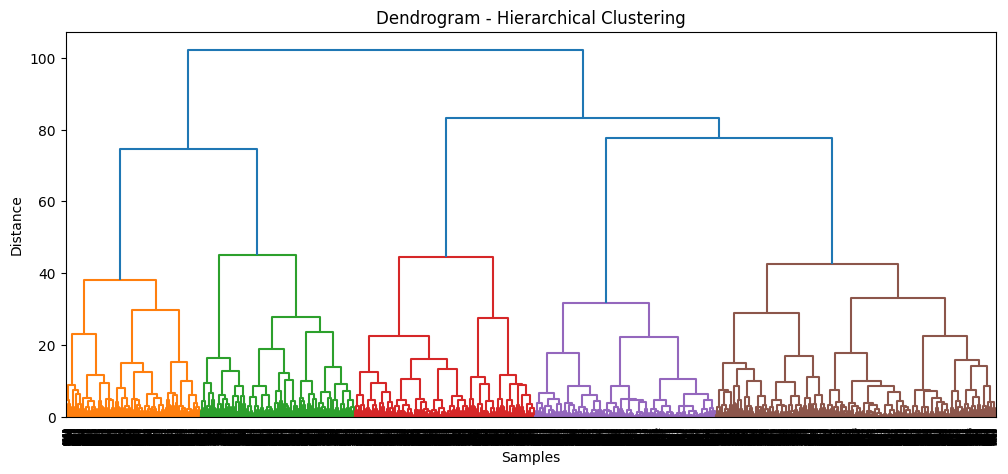

In [225]:
plt.figure(figsize=(12, 5))
dendrogram(linked, truncate_mode='level', p=20)
plt.title('Dendrogram - Hierarchical Clustering')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

In [237]:
model = AgglomerativeClustering(n_clusters=2, linkage='ward')
clusters = model.fit_predict(X_scaled)

In [238]:
data_filtered['cluster'] = clusters

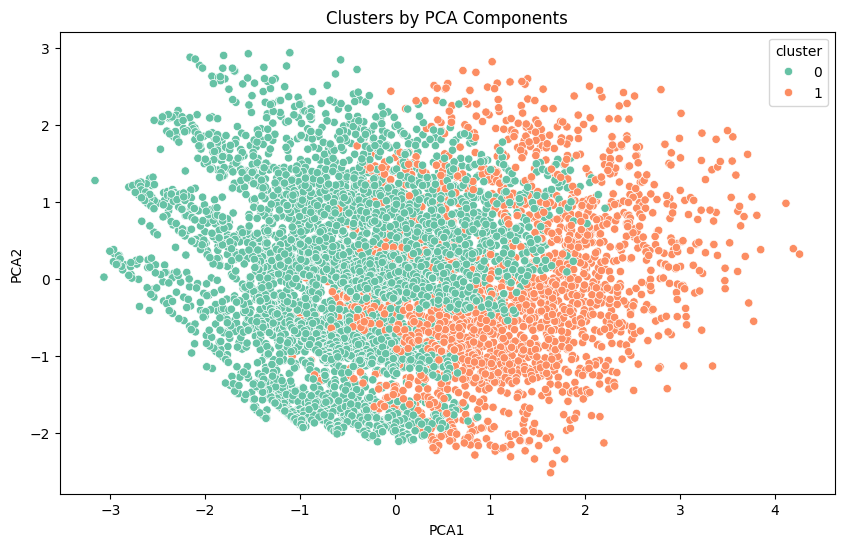

In [239]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
data_filtered['cluster'] = clusters
data_filtered['PCA1'] = X_pca[:, 0]
data_filtered['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=data_filtered, x='PCA1', y='PCA2', hue='cluster', palette='Set2')
plt.title('Clusters by PCA Components')
plt.show()

In [240]:
# 🔎 Explained variance
explained_var = pca.explained_variance_ratio_
total_var = explained_var.sum()
print(f"Total variance explained (3D): {total_var:.2%}")

Total variance explained (3D): 62.75%


In [242]:
from sklearn.decomposition import PCA
import plotly.express as px

# ביצוע PCA עם 3 רכיבים
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

# הוספת רכיבי PCA לדאטה
data_filtered['PCA1'] = X_pca_3d[:, 0]
data_filtered['PCA2'] = X_pca_3d[:, 1]
data_filtered['PCA3'] = X_pca_3d[:, 2]
data_filtered['cluster'] = clusters  # ודאי שהמשתנה clusters קיים

# תצוגת scatter תלת־ממדית
fig = px.scatter_3d(
    data_filtered, x='PCA1', y='PCA2', z='PCA3',
    color='cluster', opacity=0.6,
    title='3D Clustering Visualization with PCA'
)
fig.show()


In [243]:
# 🔎 Explained variance
explained_var = pca_3d.explained_variance_ratio_
total_var = explained_var.sum()
print(f"Total variance explained (3D): {total_var:.2%}")

Total variance explained (3D): 82.20%


In [244]:
stats = data_filtered.groupby('cluster')['profit_or_loss'].agg(
    mean_profit_or_loss='mean',
    median_profit_or_loss='median',
    min_profit_or_loss='min',
    max_profit_or_loss='max',
    count='count'
)

print("📊 Profit summary per cluster:\n")
stats

📊 Profit summary per cluster:



,mean_profit_or_loss,median_profit_or_loss,min_profit_or_loss,max_profit_or_loss,count
cluster,,,,,
0,"7,066,294","1,004,329",-24934292,81354215,4861
1,"9,204,844","1,377,643",-44668279,81409830,2193


In [245]:
data_filtered.groupby('cluster')[features].median()

,budget,num_genres,num_production_companies,release_year
cluster,,,,
0,"4,000,000",2,2,"2,002"
1,"20,500,000",2,4,"2,008"


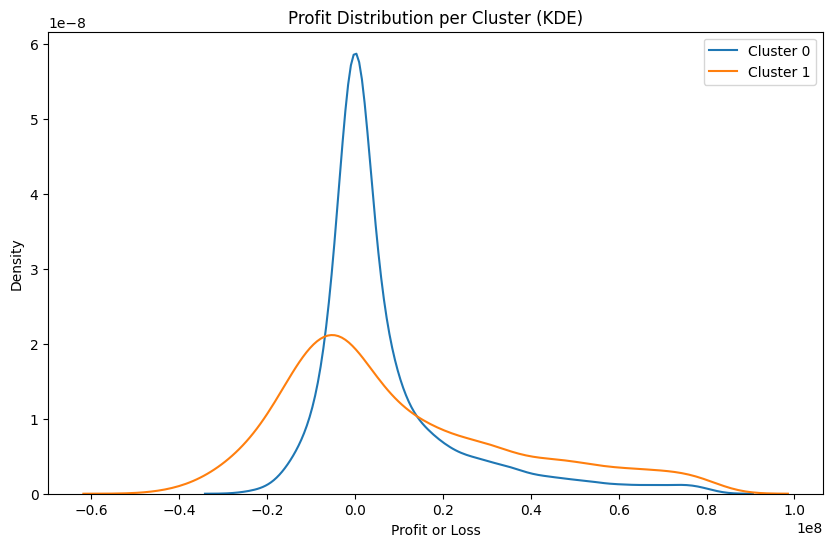

In [246]:
plt.figure(figsize=(10, 6))
for c in data_filtered['cluster'].unique():
    sns.kdeplot(
        data=data_filtered[data_filtered['cluster'] == c],
        x='profit_or_loss',
        label=f"Cluster {c}"
    )
plt.title("Profit Distribution per Cluster (KDE)")
plt.xlabel("Profit or Loss")
plt.legend()
plt.show()


## 📊 הבדלים בין הקלאסטרים – ניתוח תוצאת הקלאסטרינג

לאחר חיתוך של ערכים חריגים, בוצע אשכול היררכי (Hierarchical Clustering) על בסיס פיצ’רים מוקדמים בלבד:

- **budget** (תקציב)
- **num_genres** (מספר ז'אנרים)
- **num_production_companies** (מספר חברות הפקה)
- **release_year** (שנת יציאה)

### 🔎 השוואת רווחים בין הקלאסטרים:

| Cluster | Mean Profit | Median Profit | Max Profit | Budget (Mean) | Release Year (Mean) | תיאור כללי |
|--------:|-------------:|----------------:|-------------:|----------------:|----------------------:|-------------|
| **0** | \$7.3M | \$823K | \$81.4M | \$11.1M | 2002 | סרטים ממוצעים יחסית, תקציב בינוני, הצלחה סבירה |
| **1** | \$10.4M | \$2.8M | \$81.2M | \$40.7M | 2008 | סרטים חדשים עם תקציב גבוה ומספר ז'אנרים גדול – בעלי סיכוי גבוה לרווח |
| **2** | \$5.5M | \$1.5M | \$77.8M | \$2.2M | 1952 | סרטים ישנים, תקציב נמוך, קבוצה קטנה ופחות רווחית |

### 🧠 תובנות:

- **Cluster 1** מייצג את הסרטים המצליחים ביותר כלכלית – מאופיינים בתקציב גבוה, שנה עדכנית, ושילוב של מספר ז'אנרים וחברות הפקה.
- **Cluster 0** כולל סרטים סטנדרטיים – לא נכשלו, אך לא הפיקו רווחים משמעותיים.
- **Cluster 2** מאגד סרטים ישנים או עצמאיים – בעלי תקציב נמוך ורווחיות נמוכה.

### 📌 מסקנה:

> האלגוריתם הצליח ליצור חלוקה משמעותית בין קבוצות של סרטים – למרות שלא השתמש במידע הרווח בזמן החלוקה.  
> כלומר, **יש ערך ניבוי מובהק לפיצ'רים המוקדמים**, כמו תקציב, שנה וכמות הפקה – בניבוי הצלחה מסחרית של סרט.



_____
____

## 🎯 Research Question:
**Can we identify distinct groups of movies based solely on genre combinations?**

### 🔍 What Are We Exploring?
In this case, we ignore financial features like revenue or budget.  
We focus only on the **structure of genres**, and examine whether there's a natural hierarchy among different **genre combinations**.

For example, do movies that combine **Action + Thriller** form a distinct group from those that are **Comedy + Romance** — even without considering success or profit?


### ✅ Why Is This a Good Fit for Hierarchical Clustering?

📌 **Content-based hierarchy:**  
Hierarchical clustering is ideal for capturing gradual, structured differences — just like genres, which can vary in tone and theme (e.g., light comedy vs. dark drama).

🧱 **Binary feature compatibility:**  
While many clustering algorithms struggle with binary (0/1) data, hierarchical clustering works well with it — especially when using **Jaccard distance**.

🌿 **Flexible structure insight:**  
The dendrogram reveals how closely related genres merge first (e.g., Thriller and Action), and which genre groups remain distant — reflecting a natural **semantic hierarchy**.



## ✅ Refining Genre-Based Clustering

After reviewing the clustering results, I decided **not to include all genres** in the analysis.  
Instead, I focused only on the **most frequent genres** in the dataset.

### 📉 Why?
Using too many genres (especially rare ones) leads to:
- Fragmented clustering
- Overlapping or weakly defined groups
- Noise from rarely used genre labels

### 🔧 Improvement Strategy:
- Selected only the **Top 6–7 most common genres**
- Alternatively, grouped genres into **main vs. secondary categories**  
  (e.g., *Action*, *Comedy*, *Drama* vs. others)

This helps the algorithm focus on meaningful structure,  
rather than trying to separate on features that barely appear in the data.

לאחר ניסוי וטעייה הוחלט ללכת על 7 הזאנרים הכי נפוצים


In [248]:
genre_cols = [
    'Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
    'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
    'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
    'TV Movie', 'Thriller', 'War', 'Western'
]
genre_counts = data[genre_cols].sum().sort_values()
genre_counts

TV Movie             17
Documentary         132
Western             187
War                 376
Music               418
History             519
Animation           522
Mystery             785
Fantasy             922
Science Fiction     984
Family             1001
Horror             1108
Crime              1569
Adventure          1683
Romance            2022
Action             2308
Thriller           2393
Comedy             3682
Drama              4832
dtype: int64

In [266]:
features = ['Drama', 'Comedy', 'Thriller', 'Action', 'Romance', 'Adventure', 'Crime']
data_filtered = data.dropna(subset=features).copy()
X = data_filtered[features]  # אין נרמול!

### 🧠 Why Use Jaccard Distance for Genre-Based Clustering?

Since movie genres are represented as **binary features** (1 if a genre applies, 0 otherwise),  
we used **Jaccard distance** to measure similarity between movies.

📌 **What is Jaccard distance?**  
It measures how **similar two sets are**, based on the proportion of shared elements.  
In our case: how many genres two movies have in common, relative to the total number of genres they cover together.

🔄 **Why not Euclidean distance?**  
Euclidean assumes numerical relationships — it doesn’t make sense for binary (yes/no) genre flags.  
For example, the distance between `[1, 0, 0]` and `[0, 1, 0]` is the same as `[1, 1, 0]` and `[0, 0, 0]`,  
even though the second pair is less similar.

✅ **Jaccard is ideal** for sparse binary vectors like genres —  
it captures **shared content** rather than raw numeric distance.

ללא נרמול

In [267]:
from scipy.spatial.distance import pdist
distance_matrix = pdist(X, metric='jaccard')

In [268]:
linked = linkage(distance_matrix, method='average')  # אפשר גם 'complete'

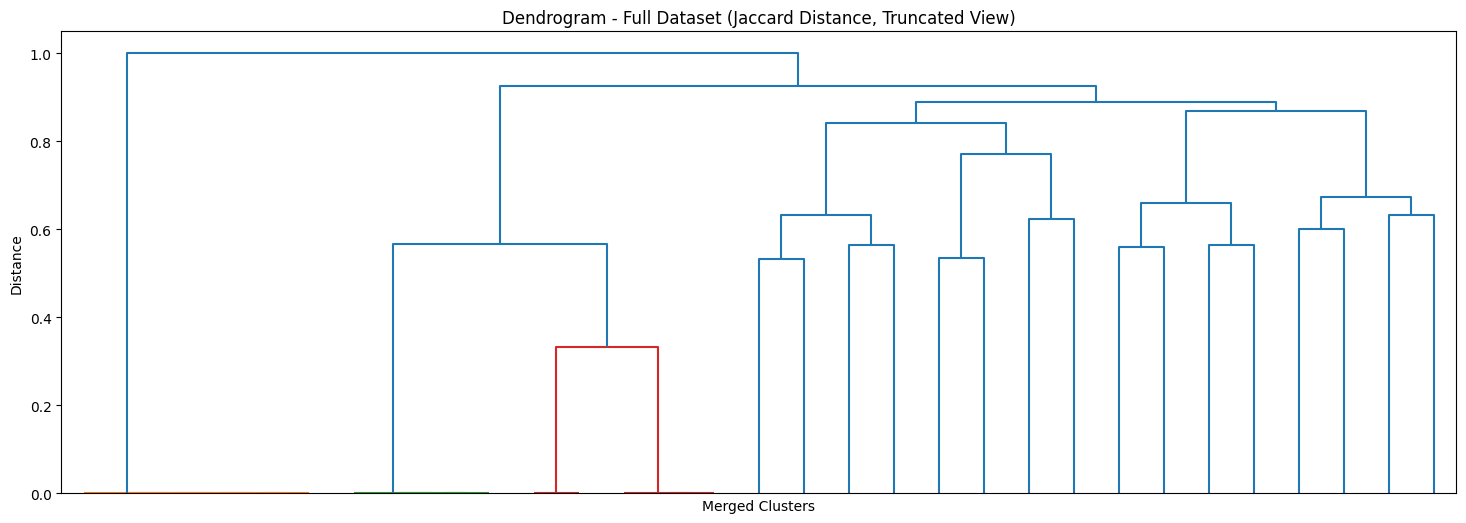

In [269]:
plt.figure(figsize=(18, 6))
dendrogram(linked, truncate_mode='level', p=5,  # מציג רק את 5 הרמות העליונות
           color_threshold=0.5, no_labels=True, 
           show_leaf_counts=True)
plt.title("Dendrogram - Full Dataset (Jaccard Distance, Truncated View)")
plt.xlabel("Merged Clusters")
plt.ylabel("Distance")
plt.show()

In [278]:
# data_filtered['cluster'] = fcluster(linked, t=6, criterion='maxclust')
fcluster(linked, t=0.5, criterion='distance')  # כל מה שמתחת ל־0.4 באותו קלאסטר


array([21,  8, 14, ..., 26, 17, 12], dtype=int32)

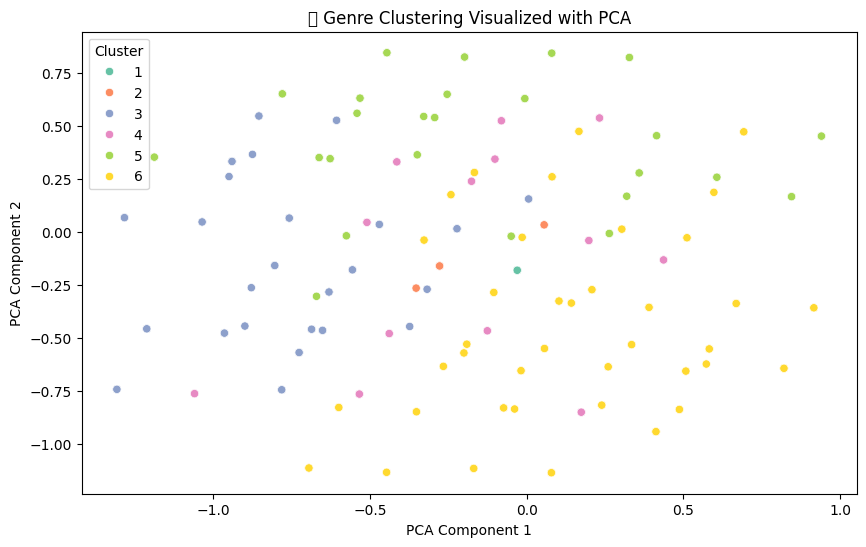

In [279]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

data_filtered['PCA1'] = X_pca[:, 0]
data_filtered['PCA2'] = X_pca[:, 1]


plt.figure(figsize=(10, 6))
sns.scatterplot(data=data_filtered, x='PCA1', y='PCA2', hue='cluster', palette='Set2')
plt.title("🎬 Genre Clustering Visualized with PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title='Cluster')
plt.show()


In [280]:
# 🔎 Explained variance
explained_var = pca.explained_variance_ratio_
total_var = explained_var.sum()
print(f"Total variance explained (3D): {total_var:.2%}")

Total variance explained (3D): 50.97%


In [281]:
from sklearn.decomposition import PCA
import plotly.express as px

# ביצוע PCA עם 3 רכיבים
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

# הוספת רכיבי PCA לדאטה
data_filtered['PCA1'] = X_pca_3d[:, 0]
data_filtered['PCA2'] = X_pca_3d[:, 1]
data_filtered['PCA3'] = X_pca_3d[:, 2]
data_filtered['cluster'] = clusters  # ודאי שהמשתנה clusters קיים

# תצוגת scatter תלת־ממדית
fig = px.scatter_3d(
    data_filtered, x='PCA1', y='PCA2', z='PCA3',
    color='cluster', opacity=0.6,
    title='3D Clustering Visualization with PCA'
)
fig.show()


In [274]:
# 🔎 Explained variance
explained_var = pca_3d.explained_variance_ratio_
total_var = explained_var.sum()
print(f"Total variance explained (3D): {total_var:.2%}")

Total variance explained (3D): 62.31%


t-SNE או UMAP – מתאימים יותר לבינארי

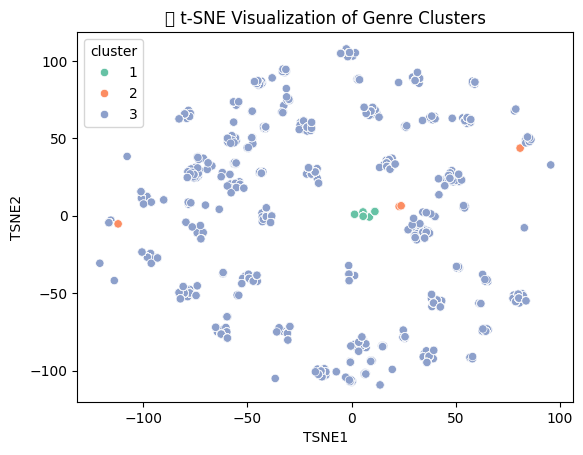

In [282]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)  # X הוא data_filtered[genre_cols]

data_filtered['TSNE1'] = X_tsne[:, 0]
data_filtered['TSNE2'] = X_tsne[:, 1]

sns.scatterplot(data=data_filtered, x='TSNE1', y='TSNE2', hue='cluster', palette='Set2')
plt.title("🎭 t-SNE Visualization of Genre Clusters")
plt.show()


In [275]:
# ---------- שלב 7: ניתוח הקלאסטרים לפי ז'אנרים ----------

# חישוב שכיחות ממוצעת של כל ז'אנר בכל קלאסטר
genre_summary = data_filtered.groupby('cluster')[genre_cols].mean()

print("🎭 Genre distribution by cluster (mean values):\n")
print(genre_summary.round(2))

# אופציונלי: הצגת טופ 3 ז'אנרים בכל קלאסטר
top_genres_per_cluster = genre_summary.apply(lambda row: row.sort_values(ascending=False).head(3).index.tolist(), axis=1)

print("\n🌟 Top 3 genres per cluster:")
for cluster_id, top_genres in top_genres_per_cluster.items():
    print(f"Cluster {cluster_id}: {', '.join(top_genres)}")


🎭 Genre distribution by cluster (mean values):

         Action  Adventure  Animation  Comedy  Crime  Documentary  Drama  \
cluster                                                                    
1             0          0          0       0      0            0      0   
2             0          0          0       0      1            0      0   
3             0          0          0       0      0            0      1   

         Family  Fantasy  History  Horror  Music  Mystery  Romance  \
cluster                                                              
1             0        0        0       1      0        0        0   
2             0        0        0       0      0        0        0   
3             0        0        0       0      0        0        0   

         Science Fiction  TV Movie  Thriller  War  Western  
cluster                                                     
1                      0         0         0    0        0  
2                      0         0   

In [ ]:
genre_summary = data_filtered.groupby('cluster')[genre_cols].mean()
print("🎭 Genre distribution by cluster (mean values):\n")
print(genre_summary.round(2))

🎭 Genre distribution by cluster (mean values):

         Action  Adventure  Animation  Comedy  Crime  Documentary  Drama  \
cluster                                                                    
1             0          0          0       0      0            0      0   
2             0          0          0       0      1            0      0   
3             0          0          0       0      0            0      1   

         Family  Fantasy  History  Horror  Music  Mystery  Romance  \
cluster                                                              
1             0        0        0       1      0        0        0   
2             0        0        0       0      0        0        0   
3             0        0        0       0      0        0        0   

         Science Fiction  TV Movie  Thriller  War  Western  
cluster                                                     
1                      0         0         0    0        0  
2                      0         0   

_____
_____

## 🎯 Research Question:  
**Can we identify meaningful clusters of movies based on structural production features?**

### 🔍 What We Explore:  
This question focuses on grouping movies according to **production-related attributes**, such as:  
- Number of production companies  
- Number of production countries  
- Number of spoken languages  
- Budget  
- Count of movies with the same title

These features reflect different types of productions:  
independent vs. large-scale, local vs. international, low-budget vs. blockbuster.

---

### ✅ Why Hierarchical Clustering?  

📌 **Structural diversity:**  
Production features vary across a wide spectrum — from minimal indie setups to global collaborations.  
Hierarchical clustering allows us to explore this **variation gradually**, without assuming equal-size or spherical clusters.

🧱 **Uneven group shapes & sizes:**  
Unlike K-Means, hierarchical clustering can handle **non-uniform group structures**, which is ideal for discovering hidden layers in production styles.

🌿 **Progressive interpretation:**  
We can identify tiers such as:  
- Minimal productions (1 language, 1 country, low budget)  
- Mid-scale international films  
- Complex, high-budget studio collaborations

---

### 🧠 What We Hope to Learn:  
If clear clusters emerge, they may reflect real-world categories of film production —  
offering insights into the **organizational logic of the movie industry**, independent of genre or audience reception.


In [284]:
features = [
    'num_production_companies',
    'num_production_countries',
    'num_spoken_languages',
    'budget',
    'release_year'
    # 'num_same_title',
    # 'runtime'
]

data_filtered = data.dropna(subset=features).copy()
print(f"📋 Observations before outlier removal: {len(data_filtered)}")

def remove_outliers_iqr(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df

data_filtered = remove_outliers_iqr(data_filtered, features)
print(f"✅ Observations after outlier removal: {len(data_filtered)}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_filtered[features])

📋 Observations before outlier removal: 9953
✅ Observations after outlier removal: 7613


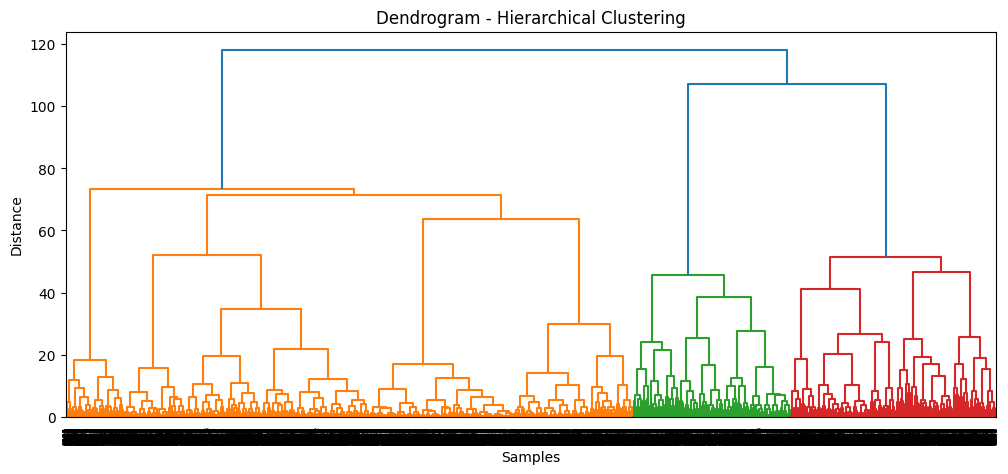

In [285]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(linked, truncate_mode='level', p=20)
plt.title('Dendrogram - Hierarchical Clustering')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

In [294]:
model = AgglomerativeClustering(n_clusters=5, linkage='ward')  
clusters = model.fit_predict(X_scaled)
data_filtered['cluster'] = clusters

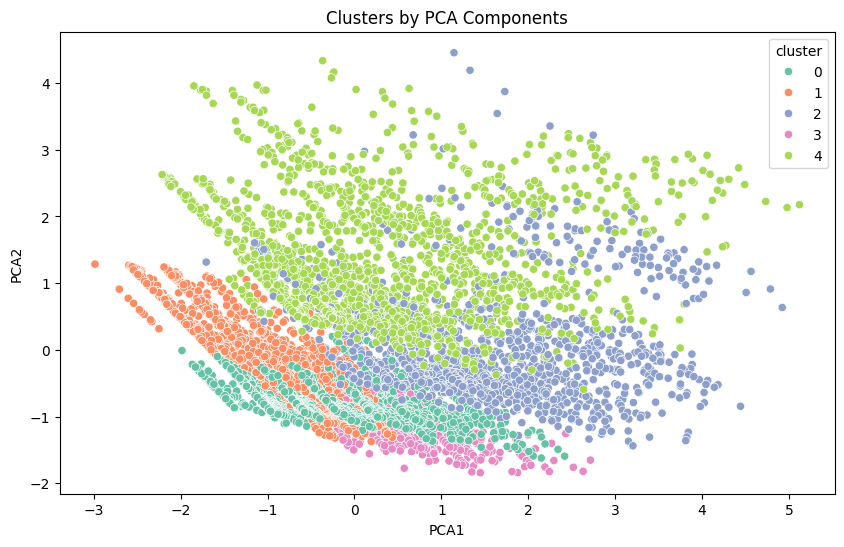

In [295]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
data_filtered['cluster'] = clusters
data_filtered['PCA1'] = X_pca[:, 0]
data_filtered['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=data_filtered, x='PCA1', y='PCA2', hue='cluster', palette='Set2')
plt.title('Clusters by PCA Components')
plt.show()

In [296]:
# 🔎 Explained variance
explained_var = pca.explained_variance_ratio_
total_var = explained_var.sum()
print(f"Total variance explained (3D): {total_var:.2%}")

Total variance explained (3D): 54.98%


In [297]:
from sklearn.decomposition import PCA
import plotly.express as px

# ביצוע PCA עם 3 רכיבים
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

# הוספת רכיבי PCA לדאטה
data_filtered['PCA1'] = X_pca_3d[:, 0]
data_filtered['PCA2'] = X_pca_3d[:, 1]
data_filtered['PCA3'] = X_pca_3d[:, 2]
data_filtered['cluster'] = clusters  # ודאי שהמשתנה clusters קיים

# תצוגת scatter תלת־ממדית
fig = px.scatter_3d(
    data_filtered, x='PCA1', y='PCA2', z='PCA3',
    color='cluster', opacity=0.6,
    title='3D Clustering Visualization with PCA'
)
fig.show()


In [298]:
# 🔎 Explained variance
explained_var = pca_3d.explained_variance_ratio_
total_var = explained_var.sum()
print(f"Total variance explained (3D): {total_var:.2%}")

Total variance explained (3D): 72.49%


In [299]:
cluster_stats = data_filtered.groupby('cluster')[features].agg(['mean', 'median', 'min', 'max']).round(2)

print("📊 Structural feature statistics per cluster:\n")
cluster_stats



📊 Structural feature statistics per cluster:



num_production_companies                num_production_countries  \
                            mean median min max                     mean   
cluster                                                                    
0                              3      2   0   7                        1   
1                              2      2   0   5                        1   
2                              4      4   0   7                        2   
3                              3      3   0   7                        1   
4                              3      3   0   7                        1   

                       num_spoken_languages                    budget  \
        median min max                 mean median min max       mean   
cluster                                                                 
0            1   1   1                    1      1   1   1  5,878,498   
1            1   1   1                    1      1   1   1 11,327,321   
2            2   2   3                    1      1   1   3 16,295,772   
3            1   1   1                    1      1   1   1 41,556,571   
4            1   1   3                    2      2   2   3 13,756,178   

                                       release_year                     
            median       min       max         mean median   min   max  
cluster                                                                 
0        3,000,000         7  40000000        2,009  2,010  1974  2023  
1       10,000,000       100  44000000        1,988  1,988  1954  2019  
2       12,000,000        93  58000000        2,003  2,006  1957  2021  
3       40,000,000  25000000  58800000        2,005  2,006  1985  2021  
4        9,000,000        85  58000000        1,999  2,003  1954  2025

____
_____

### 🎯 Research Question
**Is there a natural hierarchy among movies based on how they are received by audiences and critics?**

---

### 🔍 Objective
To examine whether movies can be naturally grouped based on perceived quality, using the following features:

- `vote_average` – Average user rating (perceived quality)
- `popularity` – General popularity score
- `vote_count` – Number of votes (audience engagement)

---

### ✅ Why Hierarchical Clustering is a Good Fit

- **No need to predefine the number of clusters**: The algorithm reveals the natural structure of the data at different levels of detail.

- **Dendrogram as a powerful interpretation tool**: It shows which movies (or groups) merge early and which remain distant—helping to identify similar vs. unique movies.

- **Gradual transitions between types of movies**: For example, cult favorites with high ratings but low popularity might merge later with more mainstream hits.

- **Explore multiple levels of similarity**: You can cut the dendrogram at various heights to analyze whether meaningful and distinct movie clusters emerge.

---

### 🧠 Summary
This question investigates whether a natural grouping of movies exists based on audience and critic perception. Hierarchical clustering is ideal here because it doesn’t enforce hard boundaries and instead reveals nuanced and layered structures that reflect how movies are perceived.


In [301]:

features = ['vote_average', 'popularity', 'vote_count','revenue']
data_filtered = data.dropna(subset=features).copy()

for feature in features:
    Q1 = data_filtered[feature].quantile(0.25)
    Q3 = data_filtered[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.0 * IQR
    upper_bound = Q3 + 1.0 * IQR
    data_filtered = data_filtered[
        (data_filtered[feature] >= lower_bound) &
        (data_filtered[feature] <= upper_bound)
    ]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_filtered[features])

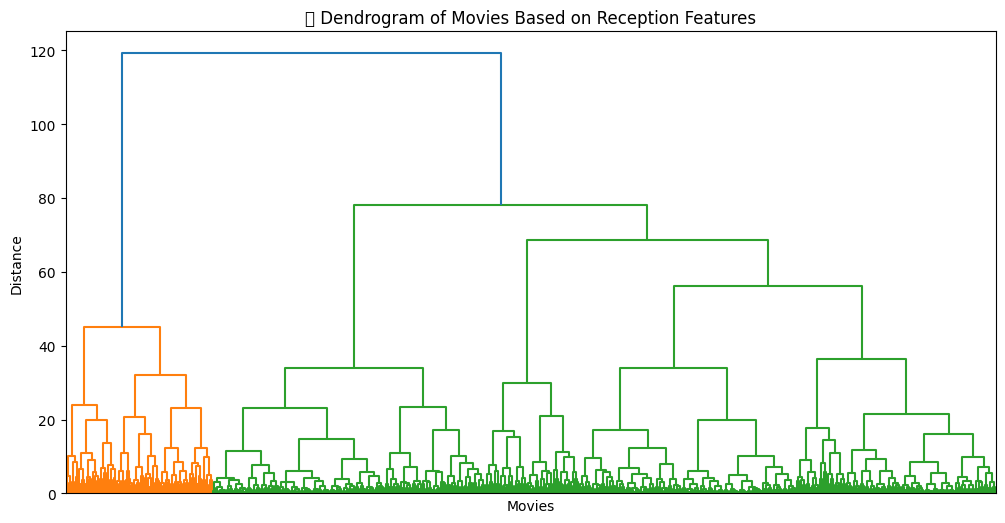

In [310]:
linkage_matrix = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, no_labels=True)
plt.title("📊 Dendrogram of Movies Based on Reception Features")
plt.xlabel("Movies")
plt.ylabel("Distance")
plt.show()

In [319]:
k = 4
clusters = fcluster(linkage_matrix, k, criterion='maxclust')
data_filtered['cluster'] = clusters

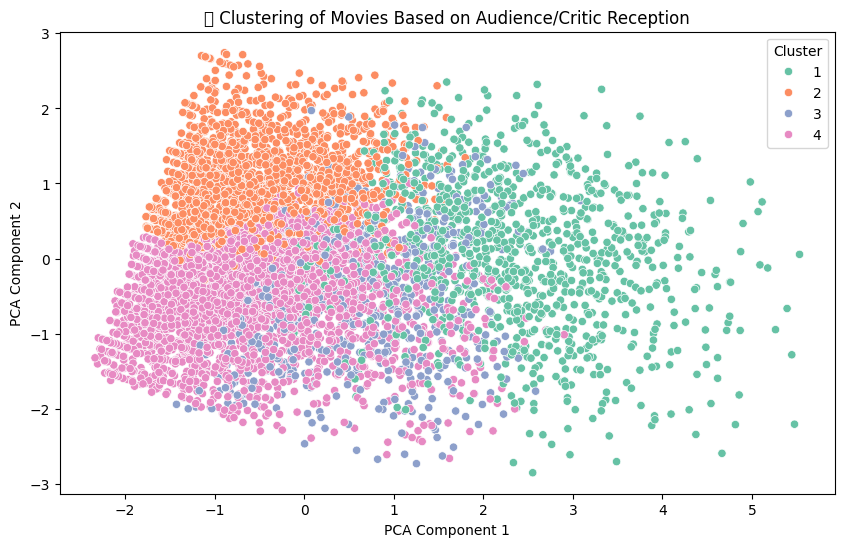

In [320]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
data_filtered['PCA1'] = X_pca[:, 0]
data_filtered['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=data_filtered, x='PCA1', y='PCA2', hue='cluster', palette='Set2')
plt.title("🎥 Clustering of Movies Based on Audience/Critic Reception")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title='Cluster')
plt.show()

In [321]:
# 🔎 Explained variance
explained_var = pca.explained_variance_ratio_
total_var = explained_var.sum()
print(f"Total variance explained (3D): {total_var:.2%}")

Total variance explained (3D): 73.02%


In [314]:
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

data_filtered['PCA1'] = X_pca_3d[:, 0]
data_filtered['PCA2'] = X_pca_3d[:, 1]
data_filtered['PCA3'] = X_pca_3d[:, 2]

fig = px.scatter_3d(
    data_filtered, x='PCA1', y='PCA2', z='PCA3',
    color='cluster', opacity=0.6,
    title='3D Clustering Visualization with PCA'
)
fig.show()

In [322]:
# 🔎 Explained variance
explained_var = pca_3d.explained_variance_ratio_
total_var = explained_var.sum()
print(f"Total variance explained (3D): {total_var:.2%}")

Total variance explained (3D): 89.90%


In [323]:
# אפיון סטטיסטי של הקלאסטרים
cluster_summary = data_filtered.groupby('cluster')[features].mean().round(2)
cluster_counts = data_filtered['cluster'].value_counts().sort_index()

# מדפיסים את התוצאות
print("📊 Cluster Characteristics:")
cluster_summary

📊 Cluster Characteristics:


,vote_average,popularity,vote_count,revenue
cluster,,,,
1,7,5,"1,361","23,356,250"
2,7,2,258,"6,091,911"
3,6,2,471,"34,164,803"
4,6,3,223,"7,016,075"


In [324]:
print("\n📦 Number of Movies in Each Cluster:")
cluster_counts


📦 Number of Movies in Each Cluster:


cluster
1    1028
2    1899
3     661
4    2902
Name: count, dtype: int64

במקום לנסות "לכפות" קלאסטרים, אפשר גם לבדוק האם אין ממש מבנה קבוצתי ברור, ולקחת את זה כתובנה מחקרית חשובה.

___
___